<a href="https://colab.research.google.com/github/devpedroandrade/classificacao-artistas-spotify/blob/main/Analise_Identidade_Sonora.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- 1. PREPARAÇÃO DOS DADOS ---
Músicas por artista após nivelamento: 99
Distribuição Balanceada:
artista
Björk            99
Gal Costa        99
Ivete Sangalo    99
Lana Del Rey     99
Madonna          99
Name: count, dtype: int64

--- 2. MODELO GAUSSIAN NAIVE BAYES ---
✅ Acurácia do Naive Bayes: 43.43%



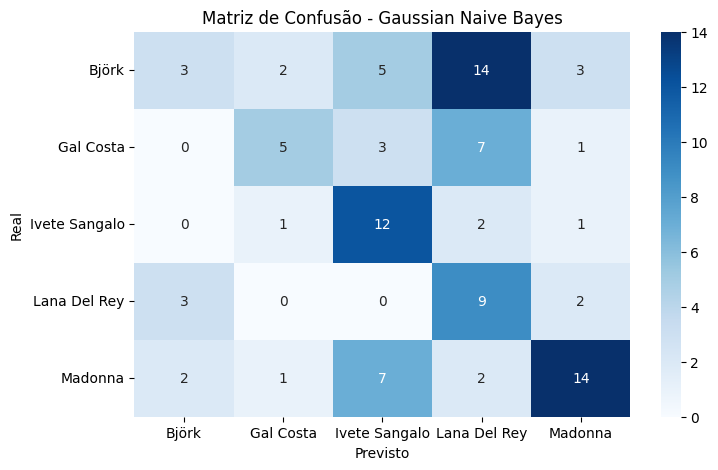

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("--- 1. PREPARAÇÃO DOS DADOS ---")
df = pd.read_csv('alltracksdoubled.csv')
df['artista'] = df['artista'].replace({'Bjork': 'Björk'})

min_musicas = df['artista'].value_counts().min()
df_balanceado = df.groupby('artista').sample(n=min_musicas, random_state=42)

df_balanceado.to_csv('alltracksdoubled_balanceado.csv', index=False)
print(f"Músicas por artista após nivelamento: {min_musicas}")
print("Distribuição Balanceada:")
print(df_balanceado['artista'].value_counts())

print("\n--- 2. MODELO GAUSSIAN NAIVE BAYES ---")
X = df_balanceado[['danceability', 'energy', 'acousticness', 'valence']]
y = df_balanceado['artista']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo_nb = GaussianNB()
modelo_nb.fit(X_train, y_train)
y_pred_nb = modelo_nb.predict(X_test)

acuracia_nb = accuracy_score(y_test, y_pred_nb)
print(f"✅ Acurácia do Naive Bayes: {acuracia_nb * 100:.2f}%\n")

plt.figure(figsize=(8, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_nb, labels=modelo_nb.classes_),
            annot=True, fmt='d', cmap='Blues', xticklabels=modelo_nb.classes_, yticklabels=modelo_nb.classes_)
plt.title('Matriz de Confusão - Gaussian Naive Bayes')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.show()

--- 3. MODELO RANDOM FOREST ---
✅ Acurácia do Random Forest: 53.54%



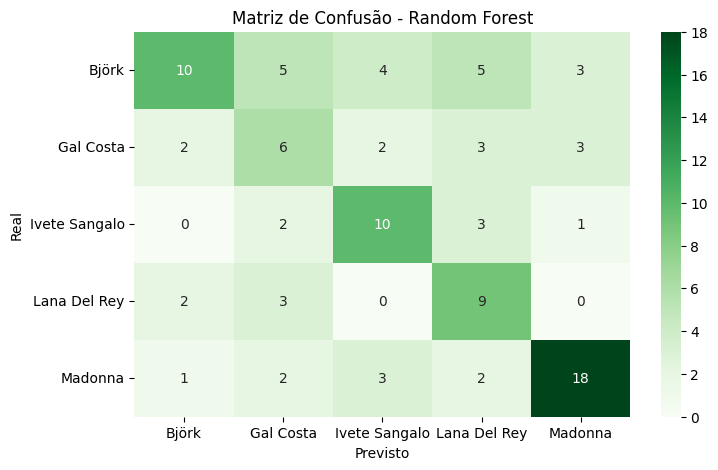


--- 4. IMPORTÂNCIA DAS VARIÁVEIS (FEATURE IMPORTANCE) ---


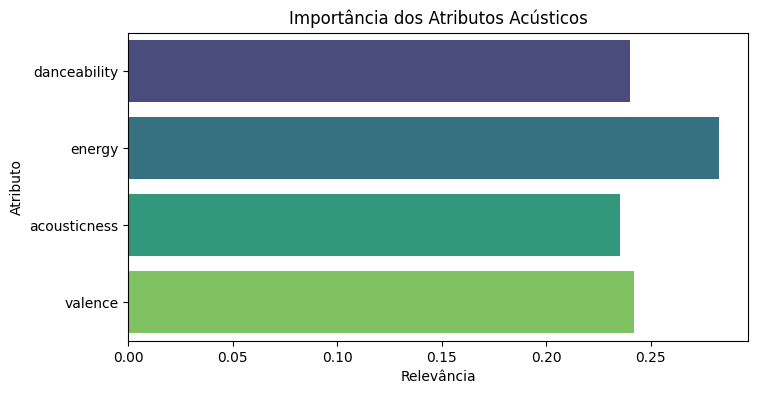

In [7]:
from sklearn.ensemble import RandomForestClassifier

print("--- 3. MODELO RANDOM FOREST ---")
df_bal = pd.read_csv('alltracksdoubled_balanceado.csv')
X = df_bal[['danceability', 'energy', 'acousticness', 'valence']]
y = df_bal['artista']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)
y_pred_rf = modelo_rf.predict(X_test)

acuracia_rf = accuracy_score(y_test, y_pred_rf)
print(f"Acurácia do Random Forest: {acuracia_rf * 100:.2f}%\n")

plt.figure(figsize=(8, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_rf, labels=modelo_rf.classes_),
            annot=True, fmt='d', cmap='Greens', xticklabels=modelo_rf.classes_, yticklabels=modelo_rf.classes_)
plt.title('Matriz de Confusão - Random Forest')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.show()

print("\n--- 4. IMPORTÂNCIA DAS VARIÁVEIS (FEATURE IMPORTANCE) ---")
importancias = modelo_rf.feature_importances_

plt.figure(figsize=(8, 4))
sns.barplot(x=importancias, y=X.columns, hue=X.columns, palette='viridis', legend=False)
plt.title('Importância dos Atributos Acústicos')
plt.xlabel('Relevância')
plt.ylabel('Atributo')
plt.show()

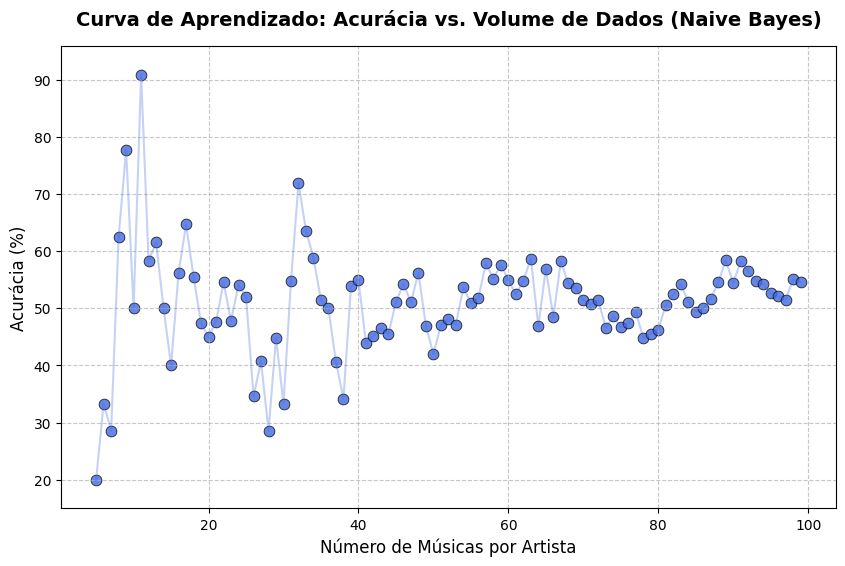

In [33]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('alltracksdoubled.csv')
df['artista'] = df['artista'].replace({'Bjork': 'Björk'})

max_musicas = df['artista'].value_counts().min()

ns_musicas = []
acuracias = []

for n in range(5, max_musicas + 1):
    df_amostra = df.groupby('artista').sample(n=n, random_state=42)

    X = df_amostra[['danceability', 'energy', 'acousticness', 'valence']]
    y = df_amostra['artista']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    modelo_nb = GaussianNB()
    modelo_nb.fit(X_train, y_train)
    y_pred = modelo_nb.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    ns_musicas.append(n)
    acuracias.append(acc * 100)

plt.figure(figsize=(10, 6))

sns.scatterplot(x=ns_musicas, y=acuracias, color='royalblue', s=60, alpha=0.8, edgecolor='black')
sns.lineplot(x=ns_musicas, y=acuracias, color='royalblue', alpha=0.3)

plt.title('Curva de Aprendizado: Acurácia vs. Volume de Dados (Naive Bayes)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Número de Músicas por Artista', fontsize=12)
plt.ylabel('Acurácia (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.ylim(min(acuracias) - 5, max(acuracias) + 5)

plt.show()

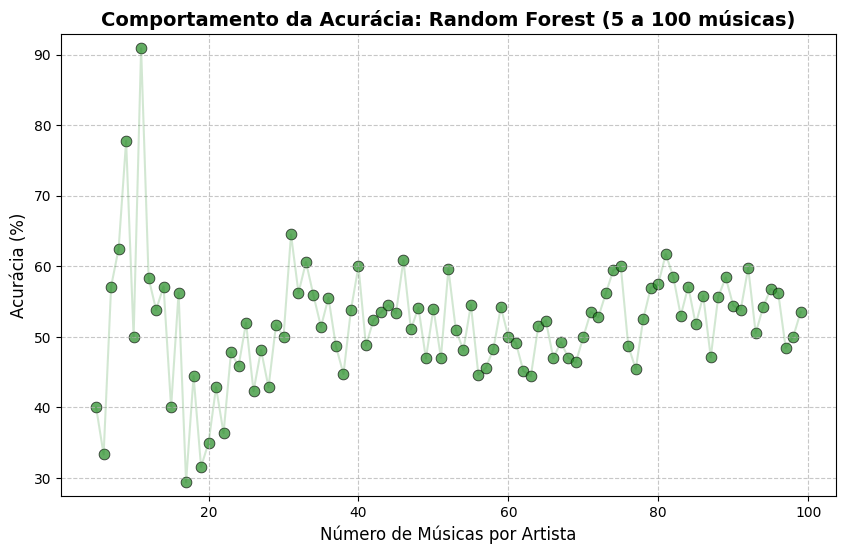

In [34]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('alltracksdoubled.csv')
df['artista'] = df['artista'].replace({'Bjork': 'Björk'})
max_musicas = df['artista'].value_counts().min()
ns_musicas = []
acuracias_rf = []

for n in range(5, max_musicas + 1):
    df_amostra = df.groupby('artista').sample(n=n, random_state=42)

    X = df_amostra[['danceability', 'energy', 'acousticness', 'valence']]
    y = df_amostra['artista']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    modelo_rf = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)
    modelo_rf.fit(X_train, y_train)
    y_pred = modelo_rf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    ns_musicas.append(n)
    acuracias_rf.append(acc * 100)

plt.figure(figsize=(10, 6))

sns.scatterplot(x=ns_musicas, y=acuracias_rf, color='forestgreen', s=60, alpha=0.7, edgecolor='black')
sns.lineplot(x=ns_musicas, y=acuracias_rf, color='forestgreen', alpha=0.2)

margin = 2.0
plt.ylim(min(acuracias_rf) - margin, max(acuracias_rf) + margin)

plt.title('Comportamento da Acurácia: Random Forest (5 a 100 músicas)', fontsize=14, fontweight='bold')
plt.xlabel('Número de Músicas por Artista', fontsize=12)
plt.ylabel('Acurácia (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

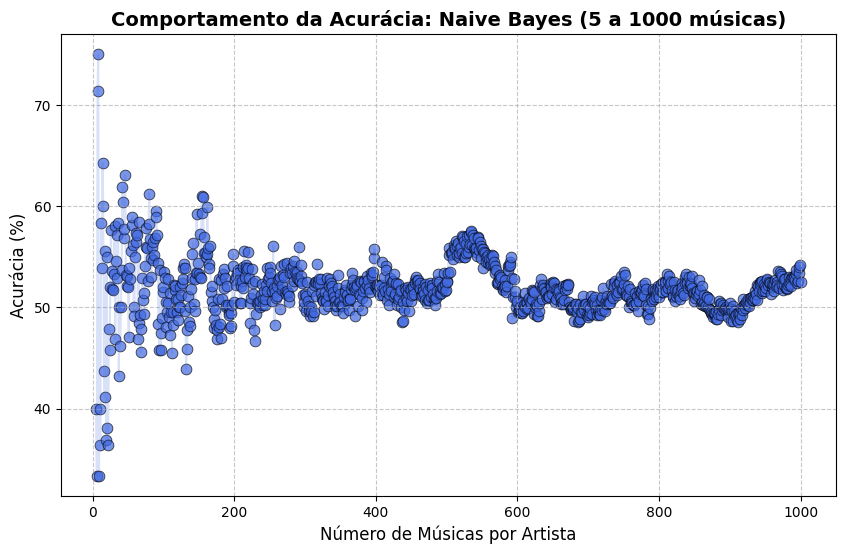

In [35]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('dataset_sintetico_1000.csv')
df['artista'] = df['artista'].replace({'Bjork': 'Björk'})

max_musicas = df['artista'].value_counts().min()
ns_musicas = []
acuracias = []

for n in range(5, max_musicas + 1):
    df_amostra = df.groupby('artista').sample(n=n, random_state=42)

    X = df_amostra[['danceability', 'energy', 'acousticness', 'valence']]
    y = df_amostra['artista']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    modelo_nb = GaussianNB()
    modelo_nb.fit(X_train, y_train)
    y_pred = modelo_nb.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    ns_musicas.append(n)
    acuracias.append(acc * 100)

plt.figure(figsize=(10, 6))

sns.scatterplot(x=ns_musicas, y=acuracias, color='royalblue', s=60, alpha=0.7, edgecolor='black')
sns.lineplot(x=ns_musicas, y=acuracias, color='royalblue', alpha=0.2)

margin = 2.0
plt.ylim(min(acuracias) - margin, max(acuracias) + margin)

plt.title('Comportamento da Acurácia: Naive Bayes (5 a 1000 músicas)', fontsize=14, fontweight='bold')
plt.xlabel('Número de Músicas por Artista', fontsize=12)
plt.ylabel('Acurácia (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

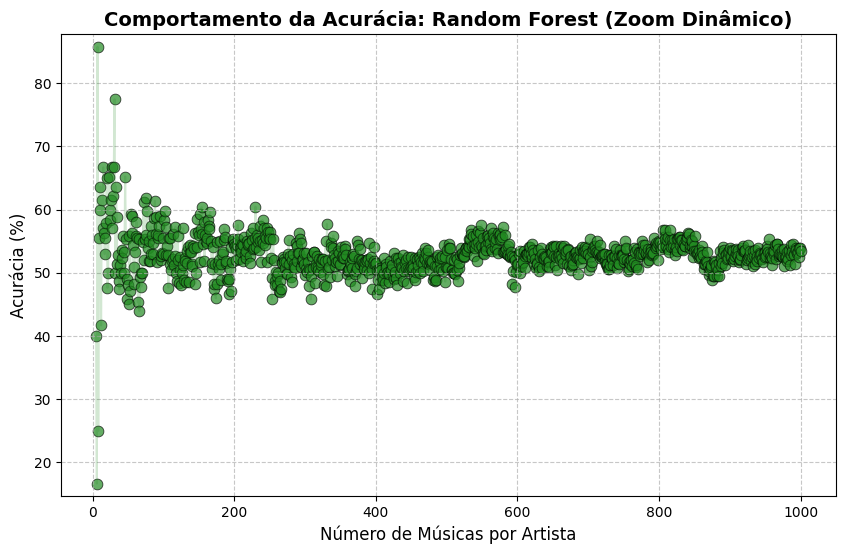

In [36]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('dataset_sintetico_1000.csv')
df['artista'] = df['artista'].replace({'Bjork': 'Björk'})

ns_musicas = []
acuracias_rf = []

for n in range(5, 1001):
    df_amostra = df.groupby('artista').sample(n=n, random_state=42)

    X = df_amostra[['danceability', 'energy', 'acousticness', 'valence']]
    y = df_amostra['artista']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    modelo_rf = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)
    modelo_rf.fit(X_train, y_train)
    y_pred = modelo_rf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    ns_musicas.append(n)
    acuracias_rf.append(acc * 100)

plt.figure(figsize=(10, 6))

sns.scatterplot(x=ns_musicas, y=acuracias_rf, color='forestgreen', s=60, alpha=0.7, edgecolor='black')
sns.lineplot(x=ns_musicas, y=acuracias_rf, color='forestgreen', alpha=0.2)

margin = 2.0
plt.ylim(min(acuracias_rf) - margin, max(acuracias_rf) + margin)

plt.title('Comportamento da Acurácia: Random Forest (Zoom Dinâmico)', fontsize=14, fontweight='bold')
plt.xlabel('Número de Músicas por Artista', fontsize=12)
plt.ylabel('Acurácia (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

In [41]:
import pandas as pd
import numpy as np

df = pd.read_csv('alltracksdoubled.csv')

df = df.dropna(subset=['artista', 'danceability', 'energy', 'acousticness', 'valence'])
df['artista'] = df['artista'].replace({'Bjork': 'Björk'})

features = ['danceability', 'energy', 'acousticness', 'valence']

dados_sinteticos = []
alvo_por_artista = 1000

for artista in df['artista'].unique():
    df_artista = df[df['artista'] == artista][features]
    qtd_atual = len(df_artista)
    qtd_necessaria = alvo_por_artista - qtd_atual

    if qtd_necessaria > 0 and qtd_atual > 1:
        media = df_artista.mean().values
        covariancia = df_artista.cov().values

        covariancia += np.eye(len(features)) * 1e-6

        amostras_sinteticas = np.random.multivariate_normal(media, covariancia, qtd_necessaria)
        amostras_sinteticas = np.clip(amostras_sinteticas, 0.0, 1.0)

        df_synth = pd.DataFrame(amostras_sinteticas, columns=features)
        df_synth['artista'] = artista
        dados_sinteticos.append(df_synth)
    elif qtd_atual <= 1:
        print(f"Ignorando artista '{artista}': possui apenas {qtd_atual} música(s).")

df_gigante = pd.concat([df] + dados_sinteticos, ignore_index=True)

artistas_com_dados_suficientes = df_gigante['artista'].value_counts()
artistas_validos = artistas_com_dados_suficientes[artistas_com_dados_suficientes >= alvo_por_artista].index

df_gigante_valido = df_gigante[df_gigante['artista'].isin(artistas_validos)]
df_gigante_balanceado = df_gigante_valido.groupby('artista').sample(n=alvo_por_artista, random_state=42)

df_gigante_balanceado.to_csv('dataset_sintetico_1000.csv', index=False)

print(f"\nDataset Gigante criado com sucesso!")
print("Distribuição Balanceada:")
print(df_gigante_balanceado['artista'].value_counts())


Dataset Gigante criado com sucesso!
Distribuição Balanceada:
artista
Björk            1000
Gal Costa        1000
Ivete Sangalo    1000
Lana Del Rey     1000
Madonna          1000
Name: count, dtype: int64


In [38]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

df = pd.read_csv('alltracksdoubled.csv')
df['artista'] = df['artista'].replace({'Bjork': 'Björk'})

max_musicas = df['artista'].value_counts().min()

def avaliar_modelo(modelo, nome_modelo, n_musicas_range):
    resultados = []
    for n in n_musicas_range:
        df_amostra = df.groupby('artista').sample(n=n, random_state=42)
        X = df_amostra[['danceability', 'energy', 'acousticness', 'valence']]
        y = df_amostra['artista']

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)

        resultados.append(accuracy_score(y_test, y_pred) * 100)

    media = np.mean(resultados)
    desvio = np.std(resultados)
    print(f"{nome_modelo}: Média = {media:.2f}% | Desvio Padrão = {desvio:.2f}%")
    return media, desvio

passo = max(1, max_musicas // 10)
range_n = range(5, max_musicas + 1, passo)

print(f"--- Calculando Estatísticas Globais (Amostras de 5 até {max_musicas}) ---")
media_nb, std_nb = avaliar_modelo(GaussianNB(), "Naive Bayes", range_n)
media_rf, std_rf = avaliar_modelo(RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42), "Random Forest", range_n)

--- Calculando Estatísticas Globais (Amostras de 5 até 99) ---
Naive Bayes: Média = 49.06% | Desvio Padrão = 11.91%
Random Forest: Média = 51.22% | Desvio Padrão = 5.43%


--- Calculando Importância Média das Variáveis (10 Rodadas) ---

🏆 A variável vencedora global é: 'energy' (Responsável por 26.9% da decisão)


/tmp/ipykernel_591/1642292719.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importância Média', y='Variável', data=df_importancia, palette='viridis')


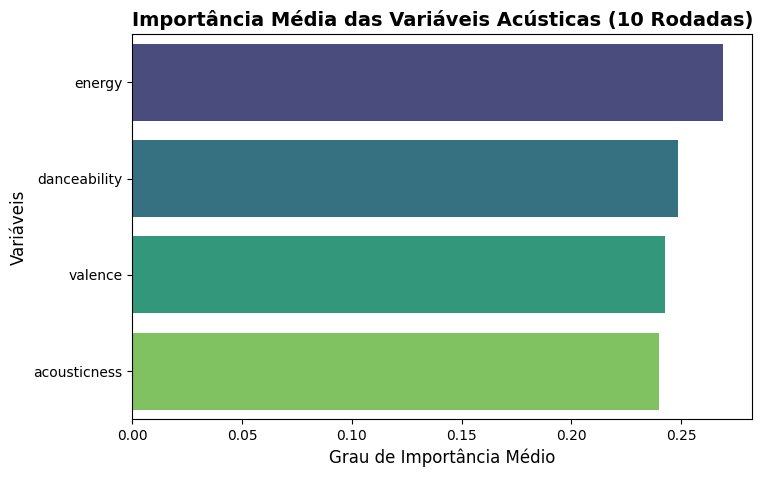

In [42]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('alltracksdoubled.csv')
df['artista'] = df['artista'].replace({'Bjork': 'Björk'})
max_musicas = df['artista'].value_counts().min()

importancias_acumuladas = []

print("--- Calculando Importância Média das Variáveis (10 Rodadas) ---")
for i in range(10):
    df_amostra = df.groupby('artista').sample(n=max_musicas, random_state=i)

    X = df_amostra[['danceability', 'energy', 'acousticness', 'valence']]
    y = df_amostra['artista']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=i, stratify=y)

    modelo_rf = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=i)
    modelo_rf.fit(X_train, y_train)

    importancias_acumuladas.append(modelo_rf.feature_importances_)

importancias_medias = np.mean(importancias_acumuladas, axis=0)
nomes_features = ['danceability', 'energy', 'acousticness', 'valence']

df_importancia = pd.DataFrame({'Variável': nomes_features, 'Importância Média': importancias_medias})
df_importancia = df_importancia.sort_values(by='Importância Média', ascending=False)

variavel_vencedora = df_importancia.iloc[0]['Variável']
peso_vencedor = df_importancia.iloc[0]['Importância Média'] * 100

print(f"\n🏆 A variável vencedora global é: '{variavel_vencedora}' (Responsável por {peso_vencedor:.1f}% da decisão)")

plt.figure(figsize=(8, 5))
sns.barplot(x='Importância Média', y='Variável', data=df_importancia, palette='viridis')
plt.title('Importância Média das Variáveis Acústicas (10 Rodadas)', fontsize=14, fontweight='bold')
plt.xlabel('Grau de Importância Médio', fontsize=12)
plt.ylabel('Variáveis', fontsize=12)
plt.show()